In [1]:
%load_ext autoreload
%autoreload 2
import os
import functools
from pathlib import Path
import numpy as np

import re
import matplotlib.pyplot as plt

imginfo = lambda img: print(type(img), img.dtype, img.shape, img.min(), img.max())


os.environ["CUDA_VISIBLE_DEVICES"]="0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
return_depth = False

dataset_location = "./data/clevr-real-block-v3"
dataset_location = Path(dataset_location)

model_location = Path("./data/models/")
model_path = model_location / "clevr-act-7-depth_text_aug" / "checkpoint-4687"

save_folder = "./data/prediction/"
Path(save_folder).mkdir(parents=True, exist_ok=True)

if "depth_depth_l40" in str(model_path):
    return_depth = True

print("dataset_location", dataset_location)
if model_path.is_dir():
    print("moadel_path is", model_path)

dataset_location data/clevr-real-block-v3
moadel_path is data/models/clevr-act-7-depth_text_aug/checkpoint-4687


dataset len 160
160


  0%|          | 0/3 [00:00<?, ?it/s]


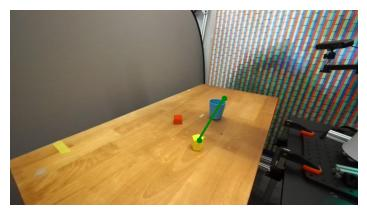
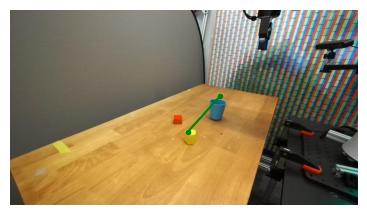
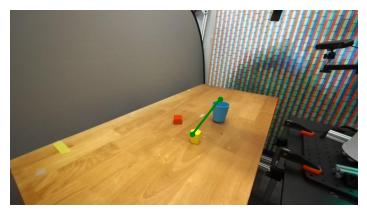

In [2]:
from data_loader_jsonl import JSONLDataset, ValidDataset
from data_augmentations import CropStart, CropMiddle, CropCenter


test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth
)

print("dataset len", len(test_dataset))

from IPython.display import display, HTML
from tqdm.notebook import tqdm
from utils_vis import render_example

def get_image(images):
    if isinstance(images, (list, tuple)):
        return images[-1]
    else:
        return images
    
def get_depth(images):
    if isinstance(images, (list, tuple)):
        return images[0]
    else:
        return None
    
print(len(test_dataset))
num_samples = 3
html_imgs = ""
for i in tqdm(range(num_samples)):
    images, sample = test_dataset[i]
    image = get_depth(images) if return_depth else get_image(images)
    html_imgs += render_example(image, label=sample["suffix"], text=sample["prefix"], camera=sample["camera"])
    
display(HTML(html_imgs))

In [3]:
import torch
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration

DEVICE = 'cuda' # torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TORCH_DTYPE = torch.bfloat16
print('Using device:', DEVICE)


MODEL_ID ="google/paligemma2-3b-pt-224"
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID)
print("loaded processor.")

def collate_fn(batch):
    images, labels = zip(*batch)
    prefixes = ["<image>" + label["prefix"] for label in labels]
    inputs = processor(
        text=prefixes,
        images=images,
        return_tensors="pt",
        padding="longest"
    ).to(TORCH_DTYPE).to(DEVICE)
    return inputs

Using device: cuda
loaded processor.


## Run beamsearch

In [4]:
save_folder = "./data/prediction/"
Path(save_folder).mkdir(parents=True, exist_ok=True)
model = PaliGemmaForConditionalGeneration.from_pretrained(model_path, torch_dtype=TORCH_DTYPE, device_map="auto")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [5]:
import math
from data_loader_jsonl import JSONLDataset, ValidDataset
from data_augmentations import CropStart, CropMiddle, CropCenter
from utils_maxim import MyProcessor, save_model_output

crop_size = 1300
test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth
)

print("dataset len", len(test_dataset))

eval_batch_size = 1
test_samples = len(test_dataset)
#test_samples = 2 # 0v, 4x, 6v, 7v, 8x, 12v, 19x

pred_list = []
html_imgs = ""
for start_idx in tqdm(range(0, test_samples, eval_batch_size), total=math.ceil(test_samples / eval_batch_size)):
    episode_indices = range(start_idx, min(start_idx + eval_batch_size, test_samples))
    batch = [test_dataset[i] for i in episode_indices]
    #for e in batch:
    #    augment_sample(e)
    inputs = collate_fn(batch) # inspect with inputs.keys()
    prefix_length = inputs["input_ids"].shape[-1]    

    with torch.inference_mode():
        # greedy
        # top-k beam search: num_beams=3, num_return_sequences=3
        
        # sampling: do_sample=True, top_k=0
        # top-k sampling: do_sample=True, top_k=10
        # top-k sampling beam search: do_sample=True, top_k=10, num_beams=3, num_return_sequences=3

        # local sampling: return_dict_in_generate=True, output_scores=True, 
        # logits_processor=[MyProcessor()], 
        # num_beams=3, 
        # num_return_sequences=3,
        generation = model.generate(**inputs, max_new_tokens=12, do_sample=False, use_cache=False, 
                                return_dict_in_generate=True, output_scores=True, 
                                logits_processor=[MyProcessor()], 
                                num_beams=3,
                                num_return_sequences=3,
                                early_stopping=True
                                )
        # inspect with generation.keys()
        decoded = [processor.decode(x, skip_special_tokens=True) for x in generation.sequences[:, prefix_length:]]
    pred_list.extend(decoded)

    
    for batch_entry, decoded_str, episode_i in zip(batch, decoded, episode_indices):
        image, sample = batch_entry

        # === save model output
        file = save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy"
        save_model_output(generation, file, save_beams=True)

        html_img = render_example(image, text=sample["prefix"], label=sample["suffix"], prediction=decoded_str, camera=sample["camera"])
        html_imgs += html_img

plot_images = True
if plot_images:
    from IPython.display import display, HTML
    display(HTML(html_imgs))

dataset len 160


  0%|          | 0/160 [00:00<?, ?it/s]

/home/argusm/miniconda3/envs/cvla/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(
--- Logging error ---
Traceback (most recent call last):
  File "/home/argusm/miniconda3/envs/cvla/lib/python3.10/logging/__init__.py", line 1100, in emit
    msg = self.format(record)
  File "/home/argusm/miniconda3/envs/cvla/lib/python3.10/logging/__init__.py", line 943, in format
    return fmt.format(record)
  File "/home/argusm/miniconda3/envs/cvla/lib/python3.10/logging/__init__.py", line 678, in format
    record.message = record.getMessage()
  File "/home/argusm/miniconda3/envs/cvla/lib/python3.10/logging/__init__.py", line 368, in getMessage
    msg = msg % self.args
TypeError: not all arguments converted during string formatting
Call stack:
  File "/home/

AttributeError: 'GenerateDecoderOnlyOutput' object has no attribute 'sequences_scores'

In [42]:
save_folder = "./data/beam3_original/"
Path(save_folder).mkdir(parents=True, exist_ok=True)

with open(save_folder + "tokens_0001_1300.npy", "rb") as f:
    sequences = np.load(f)
    scores = np.load(f)
    sequence_scores = np.load(f)
    
print("predicted text:")
print(sequences.shape)
decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]
print(decoded_str)
print("---")

print("predicted distribution")
print(scores.shape)
print("---")

predicted text:
(3, 285)
<loc0728><loc0144><loc0050><seg055><seg036><seg018><loc0443><loc0606><loc0062><seg055><seg036><seg018>
---
predicted distribution
(12, 3, 1024)
---


Text(0.5, 0, 'x')

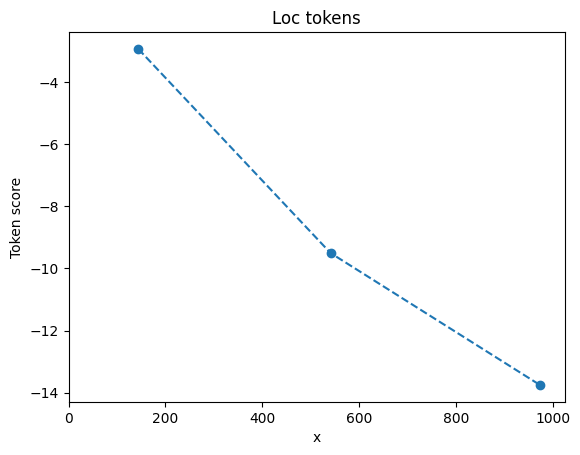

In [43]:
from utils_maxim import softmax

token_pos = 1 # obj_start (h w d rv0 rv1 rv2), obj_end (h w d rv0 rv1 rv2)
probas = scores[token_pos, 0]

fig, ax = plt.subplots()
not_inf = ~np.isinf(probas)
ax.plot(np.arange(0, 1024)[not_inf], probas[not_inf], '--')
ax.scatter(np.arange(0, 1024)[not_inf], probas[not_inf])
ax.set_xlim(0, 1024)
ax.set_ylabel("Token score")
ax.set_title("Loc tokens")
ax.set_xlabel("x")

In [44]:
# Decode all beams.
# text = prefix (text label and robot pos) + suffix (start pos and end pos)

seq = 0
print(processor.decode(sequences[seq], skip_special_tokens=True).split('\n')[1])

seq = 1
print(processor.decode(sequences[seq], skip_special_tokens=True).split('\n')[1])

seq = 2
print(processor.decode(sequences[seq], skip_special_tokens=True).split('\n')[1])

print(sequence_scores)


<loc0728><loc0144><loc0050><seg055><seg036><seg018><loc0443><loc0606><loc0062><seg055><seg036><seg018>
<loc0728><loc0144><loc0050><seg055><seg036><seg018><loc0244><loc0882><loc0078><seg055><seg036><seg018>
<loc0728><loc0144><loc0050><seg055><seg036><seg018><loc1023><loc1023><loc0033><seg055><seg036><seg018>
[-1.8307576 -1.8772146 -2.0936244]


## Evaluate

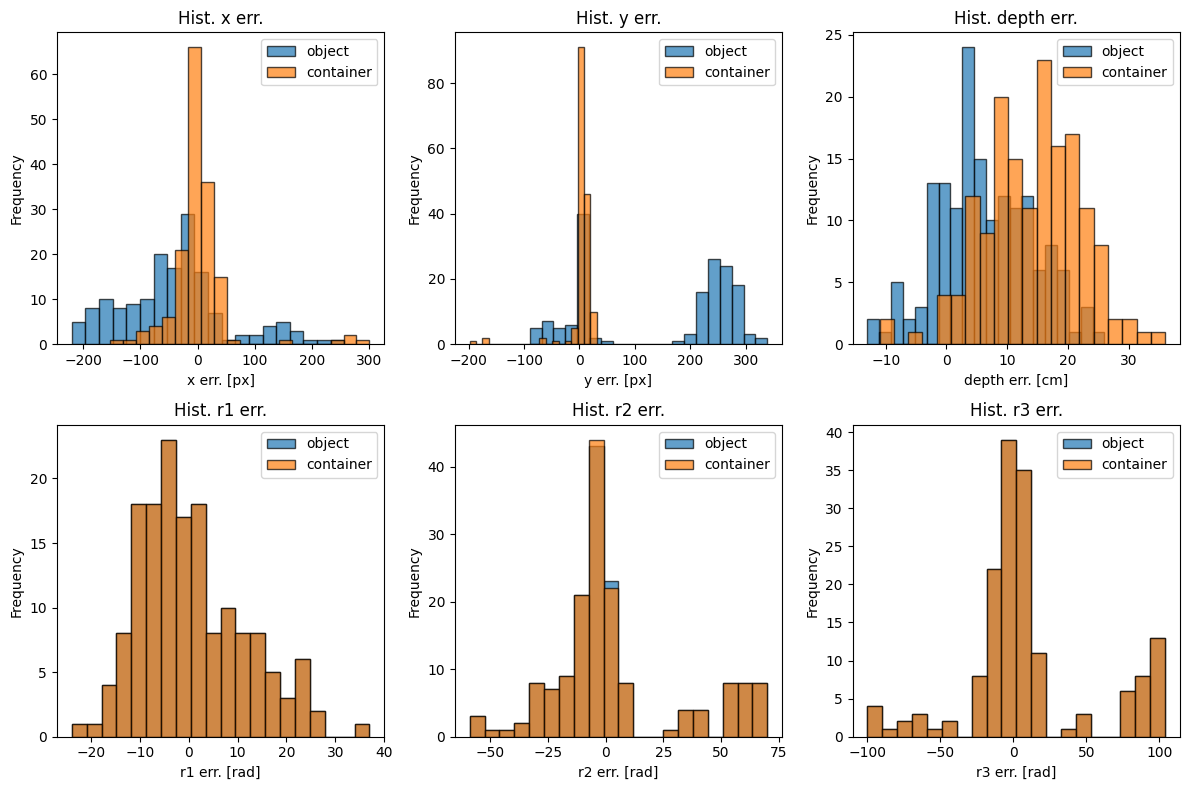

Valid Samples: 159 L1: 34.539742203878404

L1_depth 8.0062893081761


In [24]:
import re
import numpy as np
import matplotlib.pyplot as plt

# Compute results from pred_list = [decoded str i, ...]

#save_folder = "./data/greedy_original/"
#save_folder = "./data/sampling_original/"
save_folder = "./data/sampling_k10_original/"
crop_size = 1300

# Load dataset
test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth
)

# Define episodes
sample_list = list(range(len(test_dataset)))

pred_list = []
for episode_i in sample_list:
    with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
        sequences = np.load(f)
        scores =  np.load(f)
    decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]
    pred_list.append(decoded_str)

# Max part
results = []
for i, pred in enumerate(pred_list):
    suffix = test_dataset[i][1]["suffix"]
    suffix_p = [int(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", suffix)]
    decode_p = [int(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", pred)]
    if len(suffix_p) != 12 or len(decode_p) != 12:
        continue

    suffix_p = np.array(suffix_p, dtype=float)
    decode_p = np.array(decode_p, dtype=float)

    # maniskill (1024, 1024) to (image_height, image_width)
    image = test_dataset[i][0]
    h, w = image.size
    suffix_p[[0, 6]] *= h/1024
    suffix_p[[1, 7]] *= w/1024

    decode_p[[0, 6]] *= h/1024
    decode_p[[1, 7]] *= w/1024
    
    pred_diff = np.array(suffix_p) - np.array(decode_p)
    results.append(pred_diff)
results = np.array(results)

#results[:, 0:2] = results[:, 0:2]/1024*224 
#results[:, 6:8] = results[:, 6:8]/1024*224 


keypoint = ["object","container"]
action_labels = ["x","y","depth","r1","r2","r3"]*2
units         = ["px","px","cm","rad","rad","rad"]*2
plot_hist=True
if plot_hist:
    fig, axes = plt.subplots(2, 3, figsize=(12, 12*2/3))  # 3 rows x 4 columns of histograms
    axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
    for i in range(2):
        for j in range(6):
            axes[j].hist(results[:, i*6+j], bins=20, alpha=0.7,  edgecolor='black', label=keypoint[i])
            axes[j].set_title(f'Hist. {action_labels[j]} err.')
            axes[j].set_xlabel(f"{action_labels[j]} err. [{units[j]}]")
            axes[j].set_ylabel('Frequency')
            axes[j].legend()
    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

print("Valid Samples:", len(results), "L1:",np.mean(np.abs(results)))
print()
print("L1_depth", np.mean(np.abs(results[:,2])))

## Evaluate beams

In [11]:
save_folder = "data/beam3_original/"
save_folder = "data/beam_std_original/"
crop_size = 1300
episode_i = 0

with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
    sequences = np.load(f)
    scores = np.load(f)
    sequence_scores = np.load(f)

# prefix (text label and robot pos) + suffix (start pos and end pos)
decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]
print(decoded_str)

# (n_beams, encoded_steps)
print(sequences.shape)

# (steps, n_beams, n_tokens)
print(scores.shape)

# n_beams
print(sequence_scores.shape)

<loc0737><loc0150><loc0042><seg047><seg053><seg038><loc0464><loc0606><loc0044><seg047><seg053><seg038>
(3, 285)
(12, 3, 1024)
(3,)


In [12]:
# load all episodes and beams
test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth
)
test_samples = len(test_dataset)
sample_list = list(range(test_samples))

pred_list = []
score_list = [] # [i] = np.ndarray(n_beams, steps)
beam_list = [] # [i] = [beam1_str, beam2_str ...]
print_samples = 3
for episode_i in sample_list:
    if episode_i < print_samples:
        print("==== episode", episode_i)
    
    with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
        sequences = np.load(f)
        scores = np.load(f)
        sequence_scores = np.load(f)
    decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]
    
    pred_list.append(decoded_str)
    score_list.append(sequence_scores)

    beams = []
    for i in range(3):
        # prefix\nsuffix
        suffix = processor.decode(sequences[i], skip_special_tokens=True).split('\n')[1]
        beams.append(suffix)
        if episode_i < print_samples:
            print(suffix)
        
    beam_list.append(beams)


==== episode 0
<loc0737><loc0150><loc0042><seg047><seg053><seg038><loc0464><loc0606><loc0044><seg047><seg053><seg038>
<loc0737><loc0150><loc0042><seg047><seg053><seg038><loc0467><loc0606><loc0044><seg047><seg053><seg038>
<loc0737><loc0150><loc0042><seg047><seg053><seg038><loc0467><loc0606><loc0045><seg047><seg053><seg038>
==== episode 1
<loc0728><loc0144><loc0050><seg052><seg037><seg023><loc0244><loc0870><loc0081><seg052><seg037><seg023>
<loc0728><loc0144><loc0050><seg052><seg037><seg023><loc0244><loc0865><loc0081><seg052><seg037><seg023>
<loc0728><loc0144><loc0050><seg052><seg037><seg023><loc0244><loc0883><loc0082><seg052><seg037><seg023>
==== episode 2
<loc0726><loc0150><loc0041><seg057><seg059><seg030><loc0484><loc0617><loc0044><seg057><seg059><seg030>
<loc0729><loc0150><loc0041><seg057><seg059><seg030><loc0484><loc0617><loc0044><seg057><seg059><seg030>
<loc0726><loc0150><loc0041><seg057><seg059><seg030><loc0484><loc0616><loc0044><seg057><seg059><seg030>


In [13]:
# evaluate all episodes and beams
import re

# Max Argus evaluation
results = []
for i, pred in enumerate(pred_list):
    # ground truth
    suffix = test_dataset[i][1]["suffix"]
    suffix_p = [int(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", suffix)]
    decode_p = [int(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", pred)]
    
    if len(suffix_p) != 12 or len(decode_p) != 12:
        continue

    # === find beam with minimum error
    beam_error = []
    for beam_i in range(3):
        decode_p = [int(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", beam_list[i][beam_i])]
        #print(decode_p)

        pred_diff = np.mean(np.abs(np.array(suffix_p) - np.array(decode_p)))
        beam_error.append(pred_diff)
    best_beam = np.argmin(beam_error)
    decode_p = [int(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", beam_list[i][best_beam])]

    # === the most likely beam. sequence_scores are sorted by decreasing order
    most_likely = True # CHANGE ME
    if most_likely:
        decode_p = [int(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", beam_list[i][0])]


    # maniskill coors -> image coors
    suffix_p = np.array(suffix_p, dtype=float)
    decode_p = np.array(decode_p, dtype=float)
    
    image = test_dataset[i][0]
    h, w = image.size
    suffix_p[[0, 6]] *= h/1024
    suffix_p[[1, 7]] *= w/1024

    decode_p[[0, 6]] *= h/1024
    decode_p[[1, 7]] *= w/1024

    # # compare ground truth and top k local maxima
    # min_error = np.min(np.abs(ind - suffix_p[token])) # 1D array - number

    # # scale to crop size?
    # min_error = min_error / 1024.0 * crop_size
    # token_results.append(min_error)
    
    pred_diff = np.array(suffix_p) - np.array(decode_p)
    results.append(pred_diff)
results = np.array(results)

#results[:, 0:2] = results[:, 0:2]/1024*224 
#results[:, 6:8] = results[:, 6:8]/1024*224 

print("Valid Samples:", len(results), "L1:",np.mean(np.abs(results)))
print()

#print(", ".join(["{:.1f}".format(x) for x in token_mean_error]))

Valid Samples: 160 L1: 34.17615559895833



## Run greedy on original resolution

In [ ]:
import math
from data_loader_jsonl import JSONLDataset, ValidDataset
from data_augmentations import CropStart, CropMiddle, CropCenter
from utils_maxim import MyProcessor, save_model_output

crop_size = 1300
test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth
)

print("dataset len", len(test_dataset))

eval_batch_size = 1
test_samples = len(test_dataset)
#test_samples = 2 # 0v, 4x, 6v, 7v, 8x, 12v, 19x

pred_list = []
html_imgs = ""
for start_idx in tqdm(range(0, test_samples, eval_batch_size), total=math.ceil(test_samples / eval_batch_size)):
    episode_indices = range(start_idx, min(start_idx + eval_batch_size, test_samples))
    batch = [test_dataset[i] for i in episode_indices]
    #for e in batch:
    #    augment_sample(e)
    inputs = collate_fn(batch) # inspect with inputs.keys()
    prefix_length = inputs["input_ids"].shape[-1]    

    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=12, do_sample=False, use_cache=False, 
                                return_dict_in_generate=True, output_scores=True, 
                                #logits_processor=[MyProcessor()], 
                                #num_beams=3,
                                #num_return_sequences=3,
                                #early_stopping=True
                                )
        # inspect with generation.keys()
        decoded = [processor.decode(x, skip_special_tokens=True) for x in generation.sequences[:, prefix_length:]]
    pred_list.extend(decoded)

    
    for batch_entry, decoded_str, episode_i in zip(batch, decoded, episode_indices):
        image, sample = batch_entry

        # === save model output
        file = save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy"
        save_model_output(generation, file, save_beams=False)

        html_img = render_example(image, text=sample["prefix"], label=sample["suffix"], prediction=decoded_str, camera=sample["camera"])
        html_imgs += html_img

plot_images = True
if plot_images:
    from IPython.display import display, HTML
    display(HTML(html_imgs))

## Run standard beam search

dataset len 160


  0%|          | 0/2 [00:00<?, ?it/s]


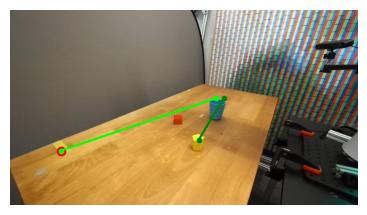
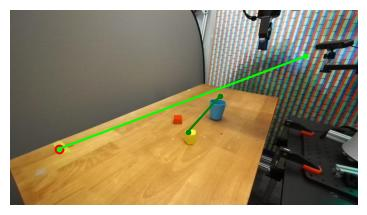

In [19]:
import math
from data_loader_jsonl import JSONLDataset, ValidDataset
from data_augmentations import CropStart, CropMiddle, CropCenter
from utils_maxim import MyProcessor, save_model_output

#save_folder = "./data/beam_std_original/"
save_folder = "./data/tmp-1/"
Path(save_folder).mkdir(parents=True, exist_ok=True)
crop_size = 1300

test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth
)

print("dataset len", len(test_dataset))

eval_batch_size = 1
#test_samples = len(test_dataset)
test_samples = 2 # 0v, 4x, 6v, 7v, 8x, 12v, 19x

pred_list = []
html_imgs = ""
for start_idx in tqdm(range(0, test_samples, eval_batch_size), total=math.ceil(test_samples / eval_batch_size)):
    episode_indices = range(start_idx, min(start_idx + eval_batch_size, test_samples))
    batch = [test_dataset[i] for i in episode_indices]
    #for e in batch:
    #    augment_sample(e)
    inputs = collate_fn(batch) # inspect with inputs.keys()
    prefix_length = inputs["input_ids"].shape[-1]    

    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=12, do_sample=False, use_cache=False, 
                                return_dict_in_generate=True, output_scores=True, 
                                #logits_processor=[MyProcessor()], 
                                num_beams=5,
                                num_return_sequences=5,
                                early_stopping=True
                                )
        # inspect with generation.keys()
        decoded = [processor.decode(x, skip_special_tokens=True) for x in generation.sequences[:, prefix_length:]]
    pred_list.extend(decoded)

    
    for batch_entry, decoded_str, episode_i in zip(batch, decoded, episode_indices):
        image, sample = batch_entry

        # === save model output
        file = save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy"
        save_model_output(generation, file, save_beams=True)

        html_img = render_example(image, text=sample["prefix"], label=sample["suffix"], prediction=decoded_str, camera=sample["camera"])
        html_imgs += html_img

plot_images = True
if plot_images:
    from IPython.display import display, HTML
    display(HTML(html_imgs))

## Run sampling

In [22]:
import math
from data_loader_jsonl import JSONLDataset, ValidDataset
from data_augmentations import CropStart, CropMiddle, CropCenter
from utils_maxim import MyProcessor, save_model_output

#save_folder = "./data/sampling__original/"
save_folder = "./data/sampling_k10_original/"
Path(save_folder).mkdir(parents=True, exist_ok=True)
crop_size = 1300

test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth
)

print("dataset len", len(test_dataset))

dataset len 160


In [ ]:
eval_batch_size = 1
test_samples = len(test_dataset)
#test_samples = 2 # 0v, 4x, 6v, 7v, 8x, 12v, 19x

pred_list = []
html_imgs = ""
for start_idx in tqdm(range(0, test_samples, eval_batch_size), total=math.ceil(test_samples / eval_batch_size)):
    episode_indices = range(start_idx, min(start_idx + eval_batch_size, test_samples))
    batch = [test_dataset[i] for i in episode_indices]
    #for e in batch:
    #    augment_sample(e)
    inputs = collate_fn(batch) # inspect with inputs.keys()
    prefix_length = inputs["input_ids"].shape[-1]    

    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=12, do_sample=True, use_cache=False, 
                                return_dict_in_generate=True, output_scores=True, 
                                top_k=10,
                                #logits_processor=[MyProcessor()], 
                                #num_beams=3,
                                #num_return_sequences=3,
                                #early_stopping=True
                                )
        # inspect with generation.keys()
        decoded = [processor.decode(x, skip_special_tokens=True) for x in generation.sequences[:, prefix_length:]]
    pred_list.extend(decoded)

    
    for batch_entry, decoded_str, episode_i in zip(batch, decoded, episode_indices):
        image, sample = batch_entry

        # === save model output
        file = save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy"
        save_model_output(generation, file, save_beams=False)

        html_img = render_example(image, text=sample["prefix"], label=sample["suffix"], prediction=decoded_str, camera=sample["camera"])
        html_imgs += html_img

plot_images = True
if plot_images:
    from IPython.display import display, HTML
    display(HTML(html_imgs))

In [ ]:
# Results on large images
# greedy 34.44
# beam search 3 beams 34.17
# my beam search 3 beams most probable 33.42
# my beam search 3 beams min error 25.01
